(13)=
# Chapter 13: Statistics & Random Sampling & Distributions

**Topics Covered:**
- Descriptive statistics: mean, median, variance, standard deviation, percentiles
- Random number generation with `numpy.random`
- Key probability distributions: uniform, normal, exponential, Poisson
- The Central Limit Theorem and why it matters in engineering
- Monte Carlo simulation: error propagation and process reliability
- Confidence intervals and hypothesis testing basics

> **Instructor Note — Chapter Opening**
>
> Welcome students and give a brief roadmap for the chapter. Say something like:
>
> *"Today we start Chapter 13 on statistics. This is one of the most practically useful chapters in the course — every single one of you will use these tools in industry. Statistics is how engineers communicate uncertainty and make decisions with imperfect data."*
>
> Mention the six topics on the slide and explain the arc: we start with summarizing real data, build up to understanding distributions, then apply everything in Monte Carlo simulation — a tool used heavily in process design, risk assessment, and pharmaceutical manufacturing.
>
> **Ask the class:** *"How many of you have taken a probability/statistics course?"* Use the show of hands to calibrate how much time to spend on fundamentals vs. applications.

In [4]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

**Motivation: Why Statistics in Chemical Engineering?**

Real engineering data is **never perfect**. Thermocouples drift. Flow meters have noise. Reaction yields vary batch to batch. Laboratory measurements have inherent uncertainty.

Statistics gives us the tools to:
1. **Summarize** data concisely (what is "typical"? how much does it vary?)
2. **Quantify uncertainty** in measured quantities
3. **Make decisions** despite noisy data (is the process on-target? is a new catalyst better?)
4. **Propagate uncertainty** through calculations (if my temperature measurement is off by 2 K, how much does that affect my computed rate constant?)

These aren't just academic exercises. Regulatory agencies (FDA, EPA) require statistical justification for process specifications. Process engineers use statistics daily for quality control, troubleshooting, and design of experiments.

---

Consider a batch reactor producing a pharmaceutical intermediate. The target yield is 88%. You run 15 batches and get:

```
85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0
```

Questions you need to answer:
- What is the average yield, and how much does it vary?
- Is the process meeting the 88% target **on average**?
- What fraction of future batches will fall below the 85% lower limit?
- How many measurements do you need to estimate the mean within ±0.5%?

All of these require statistics.

> **Instructor Note — Motivation**
>
> Read through the four bullet points slowly. For each one, give a brief real-world hook:
>
> 1. *"Summarize"* — *"If I hand you 200 temperature measurements from a reactor, the first thing you do is compute the mean and standard deviation. That's statistics."*
> 2. *"Quantify uncertainty"* — *"Every number in your lab report has uncertainty. If you don't report it, you're hiding information from whoever reads your report."*
> 3. *"Make decisions"* — *"Your process runs at 88% yield on average, but the target is 90%. Is it actually underperforming, or is that difference just noise from 10 batches of data? This is hypothesis testing."*
> 4. *"Propagate uncertainty"* — *"You measure activation energy from an Arrhenius plot with some fitting error. How does that error affect your predicted rate at 600 K? Monte Carlo answers that."*
>
> Then transition to the batch reactor example: *"Let me make this concrete. Imagine you're a process engineer at a pharma plant..."*
>
> Walk through the four questions. Emphasize that these are **not hypothetical** — this exact scenario plays out in pharmaceutical process validation (21 CFR Part 211). The FDA requires statistical justification for specifications.
>
> **Pause and ask students:** *"Without doing any math, just looking at the 15 numbers — does this process look like it's hitting the 88% target?"* Let them respond, then say you'll answer rigorously in a moment.

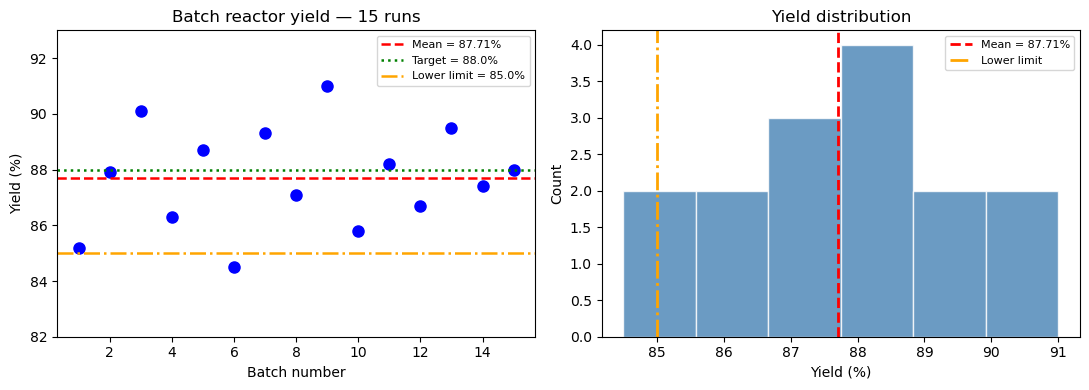

Number of batches  : 15
Mean yield         : 87.71%
Batches below 85%  : 1


In [28]:
# Batch reactor yield data (% yield)
yields = np.array([85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
                   91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw data as a dot plot
ax = axes[0]
ax.plot(range(1, len(yields)+1), yields, 'bo', markersize=8)
ax.axhline(np.mean(yields), color='red',    linestyle='--', linewidth=1.8, label=f'Mean = {np.mean(yields):.2f}%')
ax.axhline(88.0,             color='green', linestyle=':',  linewidth=1.8, label='Target = 88.0%')
ax.axhline(85.0,             color='orange',linestyle='-.',  linewidth=1.8, label='Lower limit = 85.0%')
ax.set_xlabel('Batch number')
ax.set_ylabel('Yield (%)')
ax.set_title('Batch reactor yield — 15 runs')
ax.legend(fontsize=8)
ax.set_ylim(82, 93)

# Right: histogram
ax = axes[1]
ax.hist(yields, bins=6, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(yields), color='red',    linestyle='--', linewidth=2, label=f'Mean = {np.mean(yields):.2f}%')
ax.axvline(85.0,             color='orange', linestyle='-.', linewidth=2, label='Lower limit')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Count')
ax.set_title('Yield distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Number of batches  : {len(yields)}")
print(f"Mean yield         : {np.mean(yields):.2f}%")
print(f"Batches below 85%  : {np.sum(yields < 85.0)}")

> **Instructor Note — Motivation Plot**
>
> Run the cell and let the plot render before talking. Give students a moment to look at both panels.
>
> Point to the **left panel** (dot plot): *"Each dot is one batch. The red dashed line is the sample mean — 87.7%. The green dotted line is our 88% target. The orange dash-dot is the lower limit of 85%. Visually, most batches are near the target, but the mean is slightly below it."*
>
> Point to the **right panel** (histogram): *"This is the distribution of yields. It looks roughly bell-shaped, which will be important shortly. Notice one batch fell below 85% — that's a failed batch."*
>
> Read out the printed numbers: *"Mean is 87.71%, and 1 out of 15 batches failed the lower limit. Now — is this process actually below target, or is this just random variation? We need statistics to answer that. That's exactly what confidence intervals do, and we'll get there in Section 13.5."*

(13.1)=
## 13.1 Descriptive Statistics

**Descriptive statistics** summarize the key properties of a dataset with a few numbers. Instead of reporting all 15 yield values, we report "mean 87.7%, std 1.8%" — much more useful.

There are two kinds of summary:
- **Measures of location** — where is the center of the data?
- **Measures of spread** — how much does the data vary around that center?

### Measures of location (center)

$$
\text{Mean:}\quad \bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i
\qquad\qquad
\text{Median:}\quad \text{middle value when sorted}
$$

- **Mean** is the arithmetic average — sensitive to outliers (a single extreme batch can pull it significantly)
- **Median** is the middle value — robust to outliers, better for skewed data
- For symmetric, unimodal data the two are approximately equal. A large difference between mean and median signals **skewness**.

> **ChE example:** If one batch had a catastrophic yield of 30% (contamination event), the mean would drop significantly but the median would barely move. The median better represents "typical" performance.

### Measures of spread

$$
\text{Variance:}\quad s^2 = \frac{1}{N-1}\sum_{i=1}^{N}(x_i - \bar{x})^2
\qquad\qquad
\text{Std dev:}\quad s = \sqrt{s^2}
$$

- **Variance** $s^2$ measures average squared deviation from the mean. Squaring penalizes large deviations more than small ones.
- **Standard deviation** $s$ is in the same units as the data (e.g., %), making it more interpretable.
- The **$N-1$** denominator (Bessel's correction) gives an unbiased estimate of the population variance from a sample — more on this below.

### Percentiles

The **$q$-th percentile** is the value below which $q\%$ of the data falls.
- 25th percentile = Q1 (first quartile)
- 50th percentile = Q2 = median
- 75th percentile = Q3 (third quartile)
- **Interquartile range (IQR)** = Q3 − Q1: the spread of the middle 50% of data, robust to outliers

> **ChE use:** Percentiles directly answer questions like "What yield is guaranteed 90% of the time?" This is more actionable than mean ± std for decision-making.

| Statistic | NumPy function | Notes |
|-----------|---------------|-------|
| Mean | `np.mean(x)` | Arithmetic average |
| Median | `np.median(x)` | 50th percentile |
| Variance | `np.var(x)` | `ddof=1` → sample variance (÷ N−1) |
| Std dev | `np.std(x)` | `ddof=1` → sample std dev |
| Min/Max | `np.min(x)`, `np.max(x)` | Extremes |
| Percentile | `np.percentile(x, q)` | $q$-th percentile |
| Range | `np.ptp(x)` | max − min |

**`ddof` (delta degrees of freedom):** By default NumPy uses `ddof=0` (divides by $N$), which gives the **population** variance. For a **sample** drawn from a larger population, always use `ddof=1` (divides by $N-1$) to get an unbiased estimate.

> **Instructor Note — 13.1 Descriptive Statistics**
>
> This section has a lot of content. Pace yourself — don't rush through the formulas.
>
> **On mean vs. median:** Draw two quick scenarios on the board (or describe them verbally):
> - 5 measurements: 87, 88, 89, 88, 87 → mean ≈ median (symmetric)
> - 5 measurements: 87, 88, 89, 88, 30 → mean drops dramatically, median barely moves
>
> *"The outlier of 30% (a contaminated batch) pulls the mean down by 10 points but only shifts the median one position. In industry, you'd flag that batch as an outlier and report both the full-dataset mean and the outlier-excluded mean."*
>
> **On standard deviation:** Write on the board: *"s = typical distance of a data point from the mean."* This is the most intuitive interpretation — it's not exact but it's what students should carry in their heads.
>
> **On percentiles:** Ask students: *"If I tell you the 10th percentile of batch yield is 85.4%, what does that mean in plain English?"* Wait for a response. Answer: *"10% of batches will fall below 85.4%. So if our lower spec is 85%, we expect roughly 10% of batches to fail."* This framing — **percentiles as a direct business/engineering decision tool** — is what makes statistics useful.
>
> **On the `ddof=1` table:** Point to it briefly and say you'll explain this in detail in the next sub-section. Just flag it for now.

In [6]:
# ── Descriptive statistics on the yield data ──────────────────────────────────
# Each line below answers a specific engineering question about the batch process.
print("Descriptive statistics for batch yield data")
print("-" * 45)
print(f"  N                 : {len(yields)}")
print(f"  Mean              : {np.mean(yields):.4f} %")       # best estimate of the true mean yield
print(f"  Median            : {np.median(yields):.4f} %")     # middle value — compare to mean
print(f"  Std dev (sample)  : {np.std(yields, ddof=1):.4f} %")  # typical deviation from mean
print(f"  Variance (sample) : {np.var(yields, ddof=1):.4f} %²") # std² — less intuitive but used in formulas
print(f"  Min               : {np.min(yields):.1f} %")
print(f"  Max               : {np.max(yields):.1f} %")
print(f"  Range             : {np.ptp(yields):.1f} %")        # max - min
print(f"  10th percentile   : {np.percentile(yields, 10):.2f} %")  # 10% of batches fall below this
print(f"  25th percentile   : {np.percentile(yields, 25):.2f} %  (Q1)")
print(f"  75th percentile   : {np.percentile(yields, 75):.2f} %  (Q3)")
print(f"  IQR               : {np.percentile(yields, 75) - np.percentile(yields, 25):.2f} %")

print()
print("Interpretation:")
print(f"  Mean ({np.mean(yields):.2f}%) vs Median ({np.median(yields):.2f}%) — very close,")
print(f"  suggesting a roughly symmetric distribution (no major outliers).")
print(f"  The 10th percentile ({np.percentile(yields, 10):.2f}%) tells us 10% of batches")
print(f"  will fall below this value — useful for setting lower spec limits.")

Descriptive statistics for batch yield data
---------------------------------------------
  N                 : 15
  Mean              : 87.7133 %
  Median            : 87.9000 %
  Std dev (sample)  : 1.8388 %
  Variance (sample) : 3.3812 %²
  Min               : 84.5 %
  Max               : 91.0 %
  Range             : 6.5 %
  10th percentile   : 85.44 %
  25th percentile   : 86.50 %  (Q1)
  75th percentile   : 89.00 %  (Q3)
  IQR               : 2.50 %

Interpretation:
  Mean (87.71%) vs Median (87.90%) — very close,
  suggesting a roughly symmetric distribution (no major outliers).
  The 10th percentile (85.44%) tells us 10% of batches
  will fall below this value — useful for setting lower spec limits.


> **Instructor Note — Descriptive Stats Code**
>
> Run the cell. Walk through the output line by line — don't just scroll past it.
>
> *"N = 15. Mean = 87.71%. Let's think about what that tells us: on average, we're slightly below the 88% target. But is 0.29% below target meaningful given our sample size? We'll answer that with a confidence interval later."*
>
> *"Std dev = 1.84%. Remember, this is the typical batch-to-batch variation. About 68% of batches should fall within 87.71 ± 1.84%, so between about 85.9% and 89.5%."*
>
> *"The 10th percentile is 85.44%. That means roughly 1 in 10 batches will fall below 85.44% — close to our lower spec limit of 85%."*
>
> Point to the interpretation block at the bottom: *"Mean and median are nearly equal — 87.71 vs 87.90. That symmetry suggests there are no extreme outliers pulling the mean around. If they differed by several percent, we'd investigate."*
>
> **Common student error to flag:** Many students will write `np.std(x)` without `ddof=1`. Emphasize: *"In this class, when you have experimental data, always write `ddof=1`. The default `ddof=0` gives the wrong answer for samples."*

### Why `ddof=1`? Bessel's Correction

This is a subtle but important point. When we compute the variance from a **sample**, we use the sample mean $\bar{x}$ rather than the true population mean $\mu$. This introduces a systematic bias.

**Intuition:** The sample mean $\bar{x}$ is chosen to minimize the sum of squared deviations from the data — it is "closer" to the data points than the true mean $\mu$ would be. This means the deviations $(x_i - \bar{x})$ tend to be *smaller* than the true deviations $(x_i - \mu)$. Dividing by $N-1$ instead of $N$ corrects for this systematic underestimation.

**Mathematically**, the correction ensures the sample variance is an *unbiased* estimator:

$$
s^2 = \frac{1}{N-1}\sum(x_i - \bar{x})^2
\quad \Rightarrow \quad \mathbb{E}[s^2] = \sigma^2
$$

We say we "use up" one degree of freedom by estimating the mean, leaving $N-1$ free to estimate the variance.

The effect is small for large $N$ but significant for small samples:
- $N = 5$: dividing by 4 vs 5 → **25% difference**
- $N = 10$: dividing by 9 vs 10 → **11% difference**
- $N = 100$: dividing by 99 vs 100 → **1% difference**

**Rule:** Always use `ddof=1` when working with sample data from an experiment. Only use `ddof=0` when you have the *entire* population (e.g., when you simulate all possible outcomes).

> **Instructor Note — Bessel's Correction**
>
> This is a classic sticking point. Spend 2–3 minutes on it, but don't get lost in the proof.
>
> **Intuition to emphasize:** *"When you compute deviations from the sample mean, you're measuring distances from a point that was chosen to minimize those very distances. So the deviations are artificially small — they underestimate the true spread. Dividing by N−1 corrects for that."*
>
> A useful analogy: *"It's like measuring how far students scored from the class average — they'll look closer to the average than if you measured from the true population mean, because the class average was computed from the same students."*
>
> **Stress the practical rule:** Write on the board: **`ddof=1` for experimental data, `ddof=0` for simulated populations.** Students should memorize this.
>
> Point to the table showing the magnitude of the effect: *"For N=5, the difference is 25%. For N=100, it's only 1%. This is why small-sample statistics needs to be done carefully."*

In [7]:
# ── Population vs sample variance ────────────────────────────────────────────
print("Effect of ddof on variance estimate")
print(f"  np.var(yields, ddof=0)  = {np.var(yields, ddof=0):.4f}  (population / divides by N)")
print(f"  np.var(yields, ddof=1)  = {np.var(yields, ddof=1):.4f}  (sample    / divides by N-1)")
print()
print("Manual check:")
N = len(yields)
mean_y = np.mean(yields)
ss = np.sum((yields - mean_y)**2)
print(f"  Sum of squares SS       = {ss:.4f}")
print(f"  SS / N                  = {ss/N:.4f}")
print(f"  SS / (N-1)              = {ss/(N-1):.4f}")

Effect of ddof on variance estimate
  np.var(yields, ddof=0)  = 3.1558  (population / divides by N)
  np.var(yields, ddof=1)  = 3.3812  (sample    / divides by N-1)

Manual check:
  Sum of squares SS       = 47.3373
  SS / N                  = 3.1558
  SS / (N-1)              = 3.3812


> **Instructor Note — ddof Demo**
>
> Run the cell. The output shows the manual calculation confirming the formula.
>
> *"Look at the bottom: SS = 47.34. Divide by N=15 and you get 3.16 — that's the biased (population) estimate. Divide by N−1=14 and you get 3.38 — that's the correct sample variance. The difference is small here because N is 15, but with N=5 it would be substantial."*
>
> *"`scipy.stats.describe` always uses `ddof=1` internally — it's doing the right thing by default. But `np.var()` and `np.std()` do NOT — they default to `ddof=0`. This inconsistency between libraries trips people up constantly."*

### Using `scipy.stats.describe`

`scipy.stats` provides a convenience function `describe()` that returns all basic statistics in one call.

In [8]:
# ── scipy.stats.describe ──────────────────────────────────────────────────────
desc = stats.describe(yields)
print(f"nobs     : {desc.nobs}")
print(f"min/max  : {desc.minmax}")
print(f"mean     : {desc.mean:.4f}")
print(f"variance : {desc.variance:.4f}   (uses ddof=1)")
print(f"skewness : {desc.skewness:.4f}   (0 = symmetric)")
print(f"kurtosis : {desc.kurtosis:.4f}   (0 = normal tail weight)")

nobs     : 15
min/max  : (84.5, 91.0)
mean     : 87.7133
variance : 3.3812   (uses ddof=1)
skewness : -0.0034   (0 = symmetric)
kurtosis : -0.7790   (0 = normal tail weight)


In [11]:
print(np.var(yields))
print(np.var(yields, ddof=1))

3.1558222222222203
3.381238095238093


> **Instructor Note — scipy.stats.describe**
>
> Run the cell. This is a quick one — mainly introduce the `describe()` convenience function.
>
> Point to **skewness**: *"Skewness of −0.003 is essentially zero. A perfectly symmetric distribution has skewness = 0. Positive skewness means the right tail is longer (e.g., income distributions). Negative means the left tail is longer. Our yield data is very symmetric."*
>
> Point to **kurtosis**: *"Kurtosis measures the weight of the tails. Zero here means it matches the normal distribution's tail weight (scipy uses excess kurtosis, where normal = 0). Negative kurtosis means lighter tails than normal — our data is slightly 'flatter' than a perfect bell curve, likely due to the small sample size."*
>
> *"You won't always need skewness and kurtosis, but they are useful diagnostics when checking whether data is approximately normal before applying statistical tests."*

(13.2)=
## 13.2 Random Number Generation

Many statistical tools require drawing **random samples** — either to simulate a process, test a hypothesis, or propagate uncertainty. NumPy's `numpy.random` module generates **pseudo-random** numbers: deterministic sequences that are statistically indistinguishable from true randomness.

**Why pseudo-random (not truly random)?** True randomness requires physical processes (radioactive decay, thermal noise). Pseudo-random generators use deterministic algorithms that produce sequences with excellent statistical properties. For engineering simulations, this is perfectly sufficient.

### Setting a seed

The pseudo-random generator starts from an initial state called the **seed**. Same seed → same sequence every time. This is critical for:
- **Reproducibility**: someone else runs your code and gets identical results
- **Debugging**: you can reproduce a specific run that showed unexpected behavior
- **Collaboration**: results in your notebook exactly match results in a report

```python
rng = np.random.default_rng(seed=42)   # recommended modern API

np.random.seed(42) # legacy approach 
```

Always set a seed at the top of any simulation notebook.

### Key generation functions

| Function | Distribution | Parameters |
|--------------------|-------------|------------|
| `np.random.random(n)` | Uniform [0, 1) | — |
| `np.random.uniform(low, high, n)` | Uniform [low, high) | low, high |
| `np.random.normal(mu, sigma, n)` | Normal (Gaussian) | mean $\mu$, std $\sigma$ |
| `np.random.exponential(scale, n)` | Exponential | mean = `scale` = $1/\lambda$ |
| `np.random.randint(low, high, n)` | Discrete uniform | integer range |
| `np.random.choice(a, n)` | Random selection | array `a` |
| `np.random.shuffle(a)` | Shuffle in-place | array `a` |

The `size` parameter controls the shape of the output — pass a single integer for 1-D arrays, or a tuple `(rows, cols)` for 2-D arrays.

> **Instructor Note — 13.2 Random Number Generation**
>
> Transition: *"Great — we now know how to summarize data we already have. Next we need to know how to generate data. This is the foundation of simulation."*
>
> **On pseudo-random numbers:** *"Your computer can't flip a true coin — it's a deterministic machine. Instead, it runs a mathematical algorithm that produces a sequence of numbers that looks random to any statistical test. For our purposes, this is perfectly fine."*
>
> **On seeds — spend a full minute here:** *"This is one of the most important practical habits I want you to develop. Always set a seed in any notebook that uses random numbers. Here's why: if you run a simulation, get a result, and email it to your supervisor — and they run the same code and get a different result because the random numbers differ — that's a problem. Seeds make results reproducible."*
>
> Show the `np.random.default_rng(seed=42)` syntax. Mention that 42 is arbitrary — any integer works. The point is consistency, not the specific value.
>
> **Quick code walk:** Point to the generation functions table. *"You'll use `rng.normal()` most frequently — that's your go-to for simulating measurement noise or process variability. `rng.uniform()` is for bounded uncertainty. `rng.exponential()` for time-to-failure problems. We'll use all three today."*
>
> First, np.random(n) generates random numbers from a uniform distribution between 0 and 1. That means every value in the interval from 0 up to, but not including, 1. 
>
> Now let’s move to np.normal(mu, sigma, n). This generates values from a normal distribution, also called a Gaussian distribution.
>
> np.integers(low, high, n). This generates random integers from a discrete uniform distribution. 
>
> We have np.choice(a, n). This function randomly selects elements from an array or list. For example, if a is ['A', 'B', 'C'], then np.choice(a, 5) returns 5 random selections from those options. This is useful when sampling categories, labels, or specific predefined values.
>
> np.shuffle(a) randomly shuffles the elements of an array in place.

In [34]:
import numpy as np

np.random.randint(1, 10, 2)

np.random.random(5)

array([0.68779945, 0.59780933, 0.51763046, 0.30971646, 0.75882837])

In [ ]:
import numpy as np

# np.random.seed(42)  # for reproducibility
print(np.random.uniform(0, 1, size=10))
print(np.random.normal(loc=0, scale=1, size=10))
print(np.random.randint(1, 11, size=10))

elements = ['H2O', 'CO2', 'CH4', 'N2', 'O2']
choice = np.random.choice(elements, size=3, replace=False)
print(choice)

[0.7199689  0.01136447 0.8126231  0.32723407 0.33330178 0.04130559
 0.45352568 0.45101751 0.12386414 0.77930124]
[-0.62109538 -0.33239091  0.08269055 -0.94188801 -0.77803029  1.11322829
 -1.96046373  0.25976148  0.57618245 -0.49597145]
[10  6 10  7  1  6  9 10  9  5]
['N2' 'CH4' 'CO2']


In [15]:
# ── Basic random number generation ───────────────────────────────────────────
rng = np.random.default_rng(seed=42)

# Uniform [0, 1)
u = rng.random(5)
print("Uniform [0,1):", np.round(u, 4))

# Uniform [a, b)
u2 = rng.uniform(20.0, 30.0, 5)
print("Uniform [20,30):", np.round(u2, 4))

# Normal (Gaussian)
n = rng.normal(loc=0.0, scale=1.0, size=5)
print("Standard Normal:", np.round(n, 4))

# Integers
ints = rng.integers(1, 7, size=10)    # simulates a 6-sided die
print("Dice rolls:     ", ints)

# Random selection
elements = ['H2O', 'CO2', 'CH4', 'N2', 'O2']
choice = rng.choice(elements, size=3, replace=False)
print("Random choice:  ", choice)

Uniform [0,1): [0.774  0.4389 0.8586 0.6974 0.0942]
Uniform [20,30): [29.7562 27.6114 27.8606 21.2811 24.5039]
Standard Normal: [0.8794 0.7778 0.066  1.1272 0.4675]
Dice rolls:      [3 2 1 4 6 1 6 5 2 4]
Random choice:   ['O2' 'H2O' 'N2']


> **Instructor Note — RNG Basic Code**
>
> Run the cell. Walk through each block.
>
> *"Uniform [0,1): five numbers between 0 and 1. Notice they look random — no obvious pattern. These are the raw material for everything else."*
>
> *"Uniform [20,30): we just rescaled. If your flow meter uncertainty is ±5 L/min around 25 L/min, this is what your simulated readings would look like."*
>
> *"Normal with mean 0, std 1 — the standard normal. We'll discuss this distribution in detail next."*
>
> *"Dice rolls: integers from 1 to 6. Notice `rng.integers(1, 7)` — the upper bound is exclusive, so you need 7 to get up to 6. This is a common gotcha."*
>
> *"Random choice: we picked 3 molecules from a list without replacement. Useful for bootstrapping, random sampling of experimental conditions, etc."*

### Reproducibility with seeds

In [11]:
# ── Seed reproducibility demo ─────────────────────────────────────────────────
for trial in range(3):
    rng_test = np.random.default_rng(seed=42)
    x = rng_test.normal(0, 1, 4)
    print(f"Trial {trial+1} (seed=42): {np.round(x, 4)}")

print()
for seed in [0, 1, 42]:
    rng_test = np.random.default_rng(seed=seed)
    x = rng_test.normal(0, 1, 4)
    print(f"seed={seed:>2}: {np.round(x, 4)}")

Trial 1 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 2 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 3 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]

seed= 0: [ 0.1257 -0.1321  0.6404  0.1049]
seed= 1: [ 0.3456  0.8216  0.3304 -1.3032]
seed=42: [ 0.3047 -1.04    0.7505  0.9406]


> **Instructor Note — Seed Reproducibility Demo**
>
> Run the cell. This is a short demo but the point is important.
>
> *"Trials 1, 2, and 3 all have `seed=42` — and look, all three produce identical numbers. The sequence is completely determined by the seed. This is reproducibility."*
>
> *"Now look at the three different seeds — seeds 0, 1, and 42 each give a completely different sequence. The seed is like a starting point in an enormously long random-looking sequence."*
>
> **Ask:** *"When should you NOT use a fixed seed?"* Answer: in production simulations where you genuinely want different outcomes each run (e.g., a live risk model). But for course work and published results — always fix the seed.

(13.3)=
## 13.3 Probability Distributions

A **probability distribution** is a mathematical model for a random variable. It tells us: "If we draw a value at random, how likely is each possible outcome?"

Choosing the right distribution is one of the most important modeling decisions in statistics. The wrong distribution gives wrong predictions, even with correct data.

Two broad categories:

- **Continuous distributions** — the variable can take any value in a range (temperature, concentration, flow rate, reactor yield)
- **Discrete distributions** — the variable takes only integer values (number of defects, number of events per hour)

### The PDF and CDF

For **continuous distributions**, the **probability density function (PDF)** $f(x)$ describes the relative likelihood of each value. Probabilities are obtained by integrating:

$$
P(a \leq X \leq b) = \int_a^b f(x)\, dx, \qquad \int_{-\infty}^{\infty} f(x)\, dx = 1
$$

Note: $f(x)$ itself is **not** a probability — it is a density. It can exceed 1. Only the area under the curve (integral) gives a probability.

The **cumulative distribution function (CDF)** $F(x)$ gives the probability that $X$ is less than or equal to $x$:

$$
F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t)\, dt
$$

The CDF is always between 0 and 1, and always non-decreasing. In engineering, the CDF directly answers questions like "What fraction of batches will fail the lower spec limit?"

In `scipy.stats`, every distribution object has:
- `.pdf(x)` — evaluate the PDF
- `.cdf(x)` — evaluate the CDF (probability $\leq x$)
- `.ppf(p)` — inverse CDF: find $x$ such that $P(X \leq x) = p$
- `.rvs(size)` — draw random samples

> **Instructor Note — 13.3 Probability Distributions Intro**
>
> Transition: *"Now we move to probability distributions. A distribution is a mathematical model that describes how likely different values are. We use distributions to represent uncertainty — about measurements, process conditions, material properties."*
>
> **On the PDF:** Emphasize the key conceptual point: *"The PDF f(x) is NOT a probability — it's a density. Think of it like mass per unit length. To get a probability, you integrate — you find the area under the curve. The total area is always 1."*
>
> Draw a quick sketch on the board: a bell curve, shade a region between $a$ and $b$, label it $P(a \leq X \leq b)$. This visual is worth 30 seconds.
>
> **On the CDF:** *"The CDF F(x) IS a probability — it's the probability that X is less than or equal to x. It starts at 0 and ends at 1. In scipy, `.cdf(x)` gives you this directly. This is what you'll use to answer 'what fraction of batches fail?' type questions."*
>
> **On the scipy API:** Write on the board the four methods: `.pdf()`, `.cdf()`, `.ppf()`, `.rvs()`. Tell students to memorize this pattern — it's the same for every distribution in scipy.stats.
>
> **Preview:** *"We'll cover four distributions: uniform, normal, exponential, and Poisson. Each has a natural engineering use case."*

(13.3.1)=
### 13.3.1 Uniform Distribution

Every value in the interval $[a, b]$ is equally likely — the PDF is completely flat.

$$
f(x) = \frac{1}{b - a} \text{ for } a \leq x \leq b
\qquad
\mu = \frac{a+b}{2}
\qquad
\sigma^2 = \frac{(b-a)^2}{12}
$$

**When to use it:** The uniform distribution is appropriate when you know the bounds of uncertainty but have no reason to favor any value within those bounds. It represents **maximum ignorance** within a known range.

**Engineering examples:**
- A flow meter is rated ±2% of full scale (1–100 L/min). If you have no other information about the error distribution, a uniform distribution over the error range is a reasonable default.
- A thermocouple has ±1°C accuracy stated in its spec sheet, but no further calibration data. You might model the true temperature as Uniform(T_read − 1, T_read + 1).
- Rounding errors in digital sensors — if a sensor reports integer °C, the true value is uniformly distributed within ±0.5°C of the reported value.

**scipy.stats parameterization:**
```python
stats.uniform(loc=a, scale=b-a)   # loc = lower bound, scale = width
```

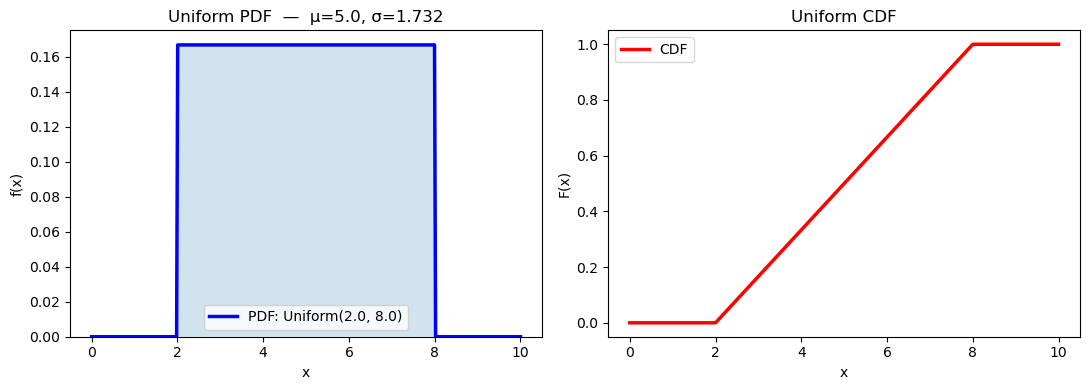

Theoretical  mean = 5.0000,  std = 1.7321
Sample       mean = 4.9737,  std = 1.7471  (n=2000)


In [ ]:
# ── Uniform distribution ─────────────────────────────────────────────────────
rng = np.random.default_rng(seed=0) # np.random.seed(0)
a, b = 2.0, 8.0

# scipy.stats.uniform: loc=a, scale=(b-a)
dist_u = stats.uniform(loc=a, scale=b - a)

x = np.linspace(0, 10, 400)
samples = rng.uniform(a, b, 2000) 
# samples = np.random.uniform(a, b, 2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# PDF + CDF
axes[0].plot(x, dist_u.pdf(x), 'b-', linewidth=2.5, label=f'PDF: Uniform({a}, {b})')
axes[0].fill_between(x, dist_u.pdf(x), alpha=0.2)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Uniform PDF  —  μ={dist_u.mean():.1f}, σ={dist_u.std():.3f}')
axes[0].legend(); axes[0].set_ylim(bottom=0)

axes[1].plot(x, dist_u.cdf(x), 'r-', linewidth=2.5, label='CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].set_title('Uniform CDF'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical  mean = {dist_u.mean():.4f},  std = {dist_u.std():.4f}")
print(f"Sample       mean = {np.mean(samples):.4f},  std = {np.std(samples, ddof=1):.4f}  (n=2000)")

> Instructor Note: 
> - dist_u represents the theoretical distribution
> - samples are random data generated from the distribution
> - pdf() shows the density of probability
> - cdf() shows the accumulated probability

In [39]:
1/6

0.16666666666666666

In [37]:
dist_u.pdf(x)

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

> **Instructor Note — Uniform Distribution Plot**
>
> Run the cell. Point to the PDF plot first.
>
> *"The PDF is completely flat between 2 and 8 — every value is equally likely. The height is 1/(8−2) = 1/6 ≈ 0.167. This ensures the area integrates to 1."*
>
> *"The CDF is a straight line going from 0 to 1. That makes sense: it's the area under a flat function, which is just proportional to width."*
>
> Point to the printed output: *"The theoretical mean is 5 — exactly in the middle between 2 and 8. The std dev is 1.732 = (8−2)/√12. With 2000 samples, we're close to the theoretical values."*
>
> **scipy gotcha to flag:** *"Notice `stats.uniform(loc=a, scale=b-a)`. The `scale` parameter is the WIDTH of the interval, not the upper bound. If you pass `scale=8` instead of `scale=6`, you get [2, 10], not [2, 8]. This catches people every time."*

(13.3.2)=
### 13.3.2 Normal (Gaussian) Distribution

The most important distribution in statistics. Symmetric, bell-shaped, described by two parameters: mean $\mu$ and standard deviation $\sigma$.

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

**When to use it:** The normal distribution arises whenever a quantity is the sum or average of many independent random contributions. This is why it appears everywhere:

**Engineering examples:**
- **Measurement error** — a thermocouple reading fluctuates due to electronic noise, vibration, and many other small independent effects. By the Central Limit Theorem (Section 13.5), their sum is normally distributed.
- **Batch-to-batch yield variation** — small variations in feed composition, temperature, mixing, and timing accumulate to produce normally distributed yields.
- **Particle size distributions** — when produced by grinding or precipitation, particle sizes often follow a log-normal distribution (normal after taking the logarithm).
- **Product specifications** — pharmaceutical purity, polymer molecular weight, and sensor calibration all tend to be normally distributed around their nominal values.

### The 68-95-99.7 rule (empirical rule)

This is the most practical fact about the normal distribution — memorize it:

$$
P(\mu - \sigma < X < \mu + \sigma) \approx 68\%
\qquad
P(\mu - 2\sigma < X < \mu + 2\sigma) \approx 95\%
\qquad
P(\mu - 3\sigma < X < \mu + 3\sigma) \approx 99.7\%
$$

**ChE application:** If batch yield is N(88%, 2%), then:
- About 68% of batches land between 86% and 90%
- About 95% of batches land between 84% and 92%
- Only 0.3% of batches fall outside 82–94% (extremely rare events)

This is the foundation of **Six Sigma** quality control — a process is "6σ" if specification limits are 6 standard deviations from the mean, meaning only 3.4 defects per million.

The **standard normal** $Z \sim \mathcal{N}(0, 1)$ arises by standardizing: $Z = (X - \mu)/\sigma$. This lets us use a single table or function for all normal distributions.

> **Instructor Note — Normal Distribution Theory**
>
> *"The normal distribution is the workhorse of engineering statistics. Spend time here — this is the distribution students will use most in their careers."*
>
> **On the formula:** You don't need to derive it, but point to the key features:
> - The $\exp(-(x-\mu)^2 / 2\sigma^2)$ term: *"This is a Gaussian — it's largest when x = μ (the peak) and decays symmetrically."*
> - The $\sigma\sqrt{2\pi}$ denominator: *"This is just a normalization constant to make the total area = 1."*
>
> **On the 68-95-99.7 rule — this is the most important thing to memorize:**
> Write on the board: **68 — 95 — 99.7**. Say it out loud. *"If you remember nothing else from today, remember these three numbers."*
>
> Work through the N(88%, 2%) example with the class:
> - *"68% of batches: between 86% and 90% — that's 88 ± 1×2"*
> - *"95% of batches: between 84% and 92% — that's 88 ± 2×2"*
> - *"99.7% of batches: between 82% and 94%"*
> - *"So if I see a batch at 93%, is that alarming? Well, it's beyond 2σ — that happens only 5% of the time. Worth investigating."*
>
> **On Six Sigma:** *"This is where 'Six Sigma' gets its name — you design processes so spec limits are 6 standard deviations away. That gives a defect rate of 3.4 per million. Companies like GE and Motorola built quality programs around this concept."*
>
> **On standardization:** *"Any normal distribution can be converted to the standard normal Z ~ N(0,1) by subtracting the mean and dividing by sigma. This is why there's only one normal distribution table — you always convert to Z first."*

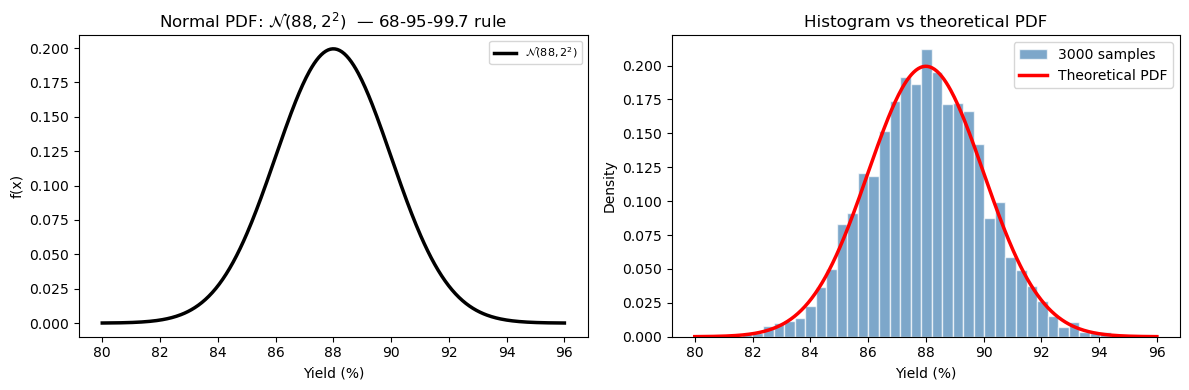

P(yield < 85%)  = 0.0668  (6.68% of batches fail lower limit)
P(yield > 92%)  = 0.0228  (2.28% of batches exceed upper limit)
P(85 ≤ yield ≤ 92%) = 0.9104


In [48]:
# ── Normal distribution ───────────────────────────────────────────────────────
rng  = np.random.default_rng(seed=1)
mu, sigma = 88.0, 2.0          # reactor yield: mean 88%, std 2%

dist_n = stats.norm(loc=mu, scale=sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
samples_n = rng.normal(mu, sigma, 3000)
# samples_n = np.random.normal(mu,sigma, 3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── PDF with shaded regions ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, dist_n.pdf(x), 'k-', linewidth=2.5, label=r'$\mathcal{N}(88, 2^2)$')

# shade ±1σ, ±2σ, ±3σ regions
# for k, color, label in [(1, 'steelblue', r'$\pm 1\sigma$ (68%)')  ,
#                          (2, 'orange',    r'$\pm 2\sigma$ (95%)')  ,
#                          (3, 'lightgreen',r'$\pm 3\sigma$ (99.7%)')]:
#     x_fill = np.linspace(mu - k*sigma, mu + k*sigma, 200)
#     ax.fill_between(x_fill, dist_n.pdf(x_fill), alpha=0.3, color=color, label=label)

ax.set_xlabel('Yield (%)')
ax.set_ylabel('f(x)')
ax.set_title(r'Normal PDF: $\mathcal{N}(88, 2^2)$  — 68-95-99.7 rule')
ax.legend(fontsize=8)

# ── Histogram of samples vs theoretical PDF ───────────────────────────────────
ax = axes[1]
ax.hist(samples_n, bins=40, density=True, color='steelblue',
        edgecolor='white', alpha=0.7, label='3000 samples')
ax.plot(x, dist_n.pdf(x), 'r-', linewidth=2.5, label='Theoretical PDF')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Density')
ax.set_title('Histogram vs theoretical PDF')
ax.legend()

plt.tight_layout()
plt.show()

# ── Key probabilities ─────────────────────────────────────────────────────────
p_below_85 = dist_n.cdf(85.0)
p_above_92 = 1 - dist_n.cdf(92.0)
print(f"P(yield < 85%)  = {p_below_85:.4f}  ({100*p_below_85:.2f}% of batches fail lower limit)")
print(f"P(yield > 92%)  = {p_above_92:.4f}  ({100*p_above_92:.2f}% of batches exceed upper limit)")
print(f"P(85 ≤ yield ≤ 92%) = {dist_n.cdf(92) - dist_n.cdf(85):.4f}")

> **Instructor Note — Normal Distribution Plot**
>
> Run the cell. Give students a moment to look at both panels.
>
> **Left panel (PDF with shaded regions):** *"The blue shading is ±1σ — covers 68% of the area. Orange is ±2σ — 95%. Green is ±3σ — 99.7%. Notice how quickly the tails fall off — events beyond 3σ are rare."*
>
> **Right panel (histogram vs PDF):** *"We drew 3000 random yield values and plotted the histogram. The red curve is the theoretical PDF. They match very closely — this is what you expect with 3000 samples. With 15 samples (like our actual data), the histogram would be much rougher."*
>
> Read the printed probabilities: *"P(yield < 85%) = 2.28%. So about 1 in 44 batches falls below the lower limit. P(yield > 92%) is also 2.28% by symmetry — same distance above the mean."*
>
> *"P(85 ≤ yield ≤ 92%) = 95.44%. This is the ±1.5σ range, which is between the 68% and 95% of the empirical rule."*
>
> **Ask the class:** *"If the lower spec limit were tightened to 87% instead of 85%, what fraction of batches would fail? Don't compute — just estimate from the 68-95-99.7 rule."* (Answer: about 16%, since 87 is 0.5σ below the mean — students may not get this exactly, but it motivates the need for `.cdf()`)

### Using the CDF and Percent Point Function (PPF)

Two of the most useful operations on a distribution are asking forward and inverse questions:

**Forward question (CDF):** "Given a value $x$, what fraction of the distribution is below it?"
$$P(X \leq x) = F(x) = \texttt{dist.cdf(x)}$$

**Inverse question (PPF):** "Given a probability $p$, what value has exactly $p \times 100\%$ of the distribution below it?"
$$x = F^{-1}(p) = \texttt{dist.ppf(p)}$$

The PPF (percent point function) is also called the **quantile function** or **inverse CDF**. It is essential for:
- Setting specification limits ("98% of batches should exceed this yield")
- Computing confidence intervals
- Finding critical values in hypothesis tests

| Question | Tool | Formula |
|----------|------|--------|
| $P(X \leq x)$ | `.cdf(x)` | Direct lookup |
| $P(X > x)$ | `1 - .cdf(x)` | Complement (survival) |
| $P(a \leq X \leq b)$ | `.cdf(b) - .cdf(a)` | Difference of CDFs |
| Find $x$ such that $P(X \leq x) = p$ | `.ppf(p)` | Inverse CDF |

> **Instructor Note — CDF and PPF**
>
> *"We just used `.cdf()` to go from a value to a probability. The PPF goes the other direction: from a probability to a value. These are the two questions you'll ask most often."*
>
> Write two question templates on the board:
> - **CDF question:** *"What fraction of observations does X fall below [value]?"* → `.cdf(value)`
> - **PPF question:** *"What value is exceeded only [p]% of the time?"* → `.ppf(1-p/100)`
>
> Give a concrete engineering example for each:
> - CDF: *"Our yield model is N(88, 2²). What fraction of batches will fail the 85% lower limit?"* → `dist.cdf(85)` = 0.0668 = 6.7%
> - PPF: *"We want to set a warning limit such that only 1% of batches trigger it. Where should that limit be?"* → `dist.ppf(0.01)` = 83.35%
>
> *"The `.cdf()` and `.ppf()` together give you full control over any probability question you can ask about a distribution."*

In [12]:
# ── CDF / PPF examples ────────────────────────────────────────────────────────
print("Using the Normal distribution  N(88, 2)")
print()
print("CDF — P(X ≤ x):")
for x_val in [84, 86, 88, 90, 92]:
    print(f"  P(yield ≤ {x_val}%) = {dist_n.cdf(x_val):.4f}")

print()
print("PPF — what yield value corresponds to the p-th percentile:")
for p in [0.01, 0.05, 0.10, 0.25, 0.50, 0.90, 0.95, 0.99]:
    print(f"  {int(100*p):>3}th percentile → yield = {dist_n.ppf(p):.2f}%")

Using the Normal distribution  N(88, 2)

CDF — P(X ≤ x):
  P(yield ≤ 84%) = 0.0228
  P(yield ≤ 86%) = 0.1587
  P(yield ≤ 88%) = 0.5000
  P(yield ≤ 90%) = 0.8413
  P(yield ≤ 92%) = 0.9772

PPF — what yield value corresponds to the p-th percentile:
    1th percentile → yield = 83.35%
    5th percentile → yield = 84.71%
   10th percentile → yield = 85.44%
   25th percentile → yield = 86.65%
   50th percentile → yield = 88.00%
   90th percentile → yield = 90.56%
   95th percentile → yield = 91.29%
   99th percentile → yield = 92.65%


> **Instructor Note — CDF/PPF Code**
>
> Run the cell. Walk through the CDF table first.
>
> *"P(yield ≤ 88%) = 0.50 — of course, since 88 is the mean of N(88, 2). Half the distribution is below the mean."*
>
> *"P(yield ≤ 84%) = 0.0228. 84 is 2 standard deviations below the mean (88 − 2×2 = 84), and 2.28% is exactly the tail beyond 2σ from the empirical rule. The rule works!"*
>
> Walk through the PPF table: *"The 5th percentile is 84.71% — meaning 5% of batches will fall below 84.71%. If our spec limit is 85%, we're in trouble: our process produces batches below spec about 5% of the time."*
>
> *"The median (50th percentile) is exactly 88% — again, because that's the mean of this symmetric distribution."*
>
> **Ask:** *"How would you use the PPF to answer: 'What yield can we guarantee at least 90% of the time?'"* Answer: `dist.ppf(0.10)` — the 10th percentile = 85.44%. So 90% of batches exceed 85.44%.

> **Instructor Note — Exponential & Poisson (Brief Mention)**
>
> *"The full notebook also covers two more distributions that come up frequently in process engineering — I'll describe them briefly here."*
>
> **Exponential distribution** — for time between random events:
> - *"If a pump fails on average every 500 hours, failure times follow Exp(scale=500). The distribution is right-skewed — most failures happen sooner than the mean, but occasionally a unit lasts a very long time."*
> - Key insight: **memorylessness** — the probability of failure in the next hour doesn't depend on how long the pump has been running. Valid for random failures, not wear-out.
> - Key property: mean = std = scale = 1/λ.
>
> **Poisson distribution** — for counts of random events in a fixed interval:
> - *"If a plant averages 3 safety incidents per year, the count in any year follows Poisson(λ=3). Unlike the others, this is a discrete distribution — only integer values."*
> - Key property: **mean = variance = λ**. If your count data has variance >> mean, you have over-dispersion.
> - Connection to exponential: if inter-event times are exponential with rate λ, then the count of events per unit time is Poisson(λ).
>
> *"Both distributions are in `scipy.stats` and follow the same `.pdf()/.cdf()/.ppf()` pattern. See the full Chapter 13 notebook for worked examples."*

(13.4)=
## 13.4 Central Limit Theorem

The **Central Limit Theorem (CLT)** is arguably the most important result in statistics. It explains why the normal distribution appears everywhere and justifies many statistical procedures even when the underlying data is not normally distributed.

> **Statement:** If you draw a sample of size $n$ from *any* distribution with finite mean $\mu$ and variance $\sigma^2$, the sample mean $\bar{X}$ is approximately normally distributed for sufficiently large $n$:
>
> $$\bar{X} \sim \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right) \qquad \text{as } n \to \infty$$

Equivalently, the **standardized** sample mean converges to a standard normal:
$$
Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)
$$

### What the CLT tells us step by step

1. **The mean of $\bar{X}$ is $\mu$** — the sample mean is an unbiased estimator of the population mean. Average many measurements and you converge to the true value.

2. **The spread of $\bar{X}$ is $\sigma/\sqrt{n}$** — this is called the **standard error of the mean (SE)**. It shrinks as $1/\sqrt{n}$. To halve the uncertainty in your mean estimate, you need 4× more data.

3. **The shape is normal** — regardless of what the original distribution looks like (uniform, exponential, bimodal, etc.), sample means become bell-shaped.

### Why it matters in ChE

- **Precision of analytical measurements:** If you analyze 5 repeat samples instead of 1, the uncertainty in your mean concentration estimate shrinks by $\sqrt{5} \approx 2.2\times$.
- **Control charts (SPC):** Statistical process control monitors sample means from batches. The CLT justifies using normal-based control limits even if individual measurements are slightly skewed.
- **Confidence intervals:** The $t$-interval (next section) is derived from the CLT — it works because sample means are approximately normal.
- **Propagation of uncertainty:** When a computed quantity is the average of many measurements, its uncertainty is the SE, not the measurement std dev.

### The standard error of the mean

$$
\text{SE} = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}
$$

The SE tells you: "How precisely do I know the population mean, given my sample?" It is always smaller than the sample standard deviation $s$, which describes individual measurement-to-measurement variation.

> **Instructor Note — Central Limit Theorem**
>
> *"The Central Limit Theorem is the reason statistics works. It's arguably the most important theorem in applied mathematics."*
>
> **Slow down here.** Students often hear the CLT as a formula and miss the intuition. Build it up in steps:
>
> **Step 1 — the mean:** *"If I draw n measurements and average them, the average converges to the true mean μ. This is the law of large numbers — you've probably heard of it."*
>
> **Step 2 — the spread:** *"The sample mean has spread σ/√n. This is called the standard error. Notice: to cut the uncertainty in half, you need 4 times more data. To cut it to 1/10, you need 100 times more data. This is why large n matters."*
>
> **Step 3 — the shape:** *"No matter what distribution your data comes from — even exponential, uniform, bimodal — the sample mean is approximately normally distributed for large n. This is the miracle."*
>
> **Draw this on the board:** A skewed distribution on the left. Then boxes showing: n=1 (still skewed), n=5 (less skewed), n=30 (bell shape). This visual is worth 2 minutes.
>
> **ChE application — measurement precision:** *"You measure a concentration 5 times and average. The uncertainty in your average is σ/√5 ≈ 0.45σ. Measure 20 times: σ/√20 ≈ 0.22σ. Each additional measurement gives diminishing returns. This is why 'run it in triplicate' is the practical standard — it's a reasonable balance between effort and precision."*
>
> **Important distinction to make:** *"The standard deviation σ describes how individual measurements vary. The standard error SE = σ/√n describes how the sample mean varies. These are different things. If you report SE instead of σ in a histogram, you're misrepresenting the data."*

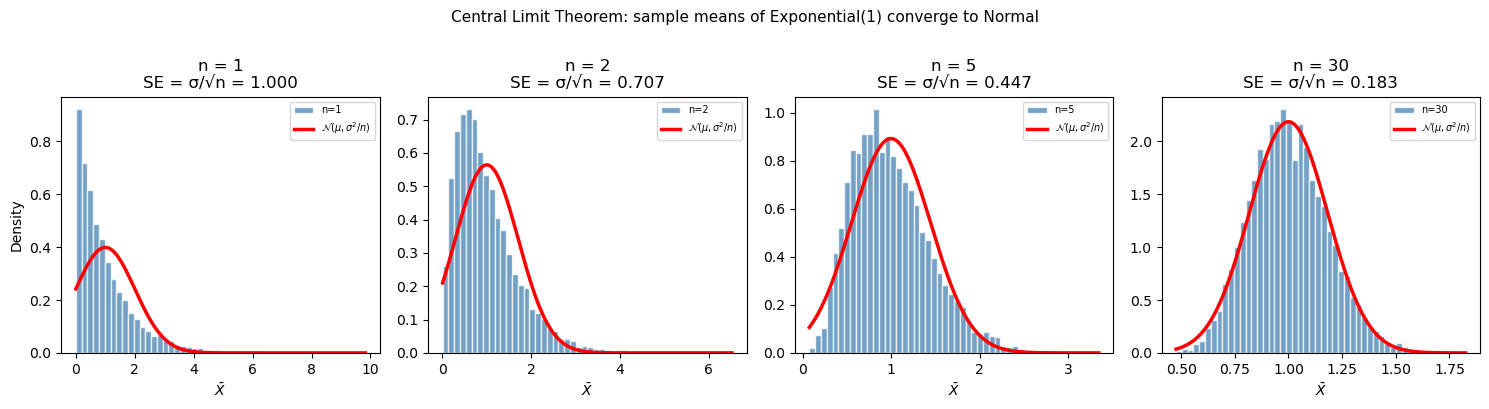

Sample size  |  SE_theory  |  SE_observed
---------------------------------------------
  n =   1     |  1.00000    |  0.99934
  n =   2     |  0.70711    |  0.71129
  n =   5     |  0.44721    |  0.45185
  n =  30     |  0.18257    |  0.18172


In [16]:
# ── Central Limit Theorem demonstration ──────────────────────────────────────
# Start from a very non-normal distribution: exponential(scale=1) → skewed
rng = np.random.default_rng(seed=99)

true_mu    = 1.0      # mean of Exp(1)
true_sigma = 1.0      # std  of Exp(1)
n_simulations = 10_000
sample_sizes  = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4), sharey=False)

for ax, n in zip(axes, sample_sizes):
    # Draw n_simulations samples of size n; compute each sample mean
    data      = rng.exponential(true_mu, size=(n_simulations, n))
    means     = data.mean(axis=1)
    se        = true_sigma / np.sqrt(n)

    ax.hist(means, bins=50, density=True, color='steelblue',
            edgecolor='white', alpha=0.75, label=f'n={n}')

    # Overlay theoretical normal
    x_range = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm(true_mu, se).pdf(x_range),
            'r-', linewidth=2.5, label=r'$\mathcal{N}(\mu,\sigma^2/n)$')

    ax.set_title(f'n = {n}\nSE = σ/√n = {se:.3f}')
    ax.set_xlabel(r'$\bar{X}$')
    ax.set_ylabel('Density' if n == 1 else '')
    ax.legend(fontsize=7)

plt.suptitle('Central Limit Theorem: sample means of Exponential(1) converge to Normal',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("Sample size  |  SE_theory  |  SE_observed")
print("-" * 45)
for n in sample_sizes:
    data  = rng.exponential(true_mu, size=(n_simulations, n))
    means = data.mean(axis=1)
    print(f"  n = {n:>3}     |  {true_sigma/np.sqrt(n):.5f}    |  {np.std(means, ddof=1):.5f}")

> **Instructor Note — CLT Demo**
>
> This is one of the most visually compelling demos in the course. Let it breathe.
>
> Run the cell and point to the four panels left-to-right:
>
> *"We start with exponential data — very right-skewed. n=1: the histogram of single draws looks exactly like an exponential. Still highly skewed."*
>
> *"n=2: we're averaging pairs. Already less skewed — the right tail is pulling in."*
>
> *"n=5: starting to look bell-shaped. The red curve — which is the theoretical normal — is already a decent fit."*
>
> *"n=30: nearly perfect match with the normal distribution. Starting from an exponential! This is the Central Limit Theorem in action."*
>
> Point to the SE values in the titles: *"Notice SE shrinks: 1.0 → 0.707 → 0.447 → 0.183. Each time we quadruple n, SE halves."*
>
> Read the table at the bottom: *"The theoretical SE matches the observed SE from 10,000 simulations very closely. The CLT is not an approximation for this demo — it's essentially exact at n=30."*
>
> **Ask the class:** *"At what n would you say the approximation is 'good enough' for practical use?"* Typical engineering answer: n ≥ 30 for roughly symmetric data, n ≥ 50 for highly skewed data. For the exponential, n=30 is already excellent.

(13.5)=
## 13.5 Confidence Intervals

After computing a sample mean $\bar{x}$, we know this is our best estimate of the true population mean $\mu$ — but how good is that estimate? A **confidence interval (CI)** quantifies this uncertainty by giving a range of plausible values for $\mu$.

### What a confidence interval means (carefully)

A 95% CI does **not** mean "there is a 95% probability that $\mu$ is in this interval." The true $\mu$ is a fixed (unknown) number — it is either in the interval or it isn't.

The correct interpretation: **if we repeated the experiment many times and built a 95% CI each time, 95% of those intervals would contain the true mean.** The confidence is in the *procedure*, not in any single interval.

In practice, we say "we are 95% confident the true mean lies in [lo, hi]" — a shorthand for the above.

---

### Step-by-step: How to compute a CI

**Step 1:** Compute the sample mean $\bar{x}$, sample standard deviation $s$, and sample size $n$.

**Step 2:** Compute the **standard error**: $\text{SE} = s/\sqrt{n}$

**Step 3:** Choose a confidence level (90%, 95%, 99%) and find the critical value.

**Step 4:** Compute the **margin of error**: $m = t_{\alpha/2,\, n-1} \times \text{SE}$

**Step 5:** The CI is $[\bar{x} - m,\; \bar{x} + m]$

---

### CI for the mean — known σ (Z-interval)

If the population standard deviation $\sigma$ is known (rare in practice) or $n$ is large ($n \gtrsim 30$):

$$
\bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}
$$

where $z_{\alpha/2}$ is from the standard normal. Common values: $z_{0.025} = 1.96$ (95% CI), $z_{0.005} = 2.576$ (99% CI).

### CI for the mean — unknown σ (t-interval)

With small samples and unknown $\sigma$ (the usual case in engineering), use the **Student's t-distribution** with $\nu = n - 1$ degrees of freedom:

$$
\bar{x} \pm t_{\alpha/2,\, n-1} \frac{s}{\sqrt{n}}
$$

**Why t instead of z?** When we estimate $\sigma$ from data as $s$, we introduce additional uncertainty — especially for small $n$. The $t$-distribution has heavier tails than the normal, which accounts for this. As $n \to \infty$, $s \to \sigma$ and the $t$-distribution converges to the standard normal.

| $n$ | $t_{0.025,\, n-1}$ (for 95% CI) | Notes |
|----|----------------------------------|-------|
| 5  | 2.776 | Much wider than z! |
| 10 | 2.228 | Still wider |
| 20 | 2.093 | Close to z |
| 30 | 2.045 | Nearly z |
| ∞  | 1.960 (→ z) | Converges |

**ChE practical rule:** Use the $t$-interval for sample sizes up to ~30. Above that, the difference from the $z$-interval is negligible. With small samples ($n < 10$), the $t$-interval can be substantially wider — this is appropriate, because you truly have less information.

> **Instructor Note — Confidence Intervals**
>
> *"We can now answer the question we posed at the beginning: is our batch process actually hitting the 88% target?"*
>
> **On the interpretation — be very precise here:** Students almost universally misstate this. Write on the board:
>
> ❌ *"There is a 95% probability that μ is in the interval."*
> ✓ *"If we repeated this experiment many times, 95% of the intervals we compute would contain μ."*
>
> *"μ is a fixed number — it's either in our interval or it isn't. The 95% refers to the reliability of the procedure, not a probability about μ."*
>
> **Walk through the 5 steps on the board** as you explain them:
> 1. Compute x̄, s, n
> 2. SE = s/√n
> 3. Choose confidence level → find t-critical
> 4. Margin = t × SE
> 5. CI = [x̄ − margin, x̄ + margin]
>
> **On t vs z:** *"Why t and not z? Because we don't know the true σ — we're estimating it with s from the same 15 data points. That extra uncertainty means the interval needs to be wider. The t-distribution has heavier tails to account for this."*
>
> Point to the t-table: *"With n=5, the t-critical for 95% is 2.776 — significantly larger than 1.96 from the normal. With n=30, it's 2.045 — almost identical to 1.96. The t-distribution converges to normal as n grows."*
>
> **Rule to write on board:** *"n < 30: always use t. n ≥ 30: t and z give nearly identical results."*

In [17]:
# ── Confidence interval for yield data ───────────────────────────────────────
n    = len(yields)
xbar = np.mean(yields)
s    = np.std(yields, ddof=1)
se   = s / np.sqrt(n)

print(f"Sample: n={n}, mean={xbar:.4f}%, s={s:.4f}%, SE={se:.4f}%")
print()

for conf in [0.90, 0.95, 0.99]:
    alpha = 1 - conf
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * se
    lo, hi = xbar - margin, xbar + margin
    print(f"{int(100*conf)}% CI:  [{lo:.4f}, {hi:.4f}]%   (t_crit = {t_crit:.3f}, margin = ±{margin:.4f})")

print()
# scipy convenience function — equivalent result
lo95, hi95 = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f"scipy.stats.t.interval(0.95): [{lo95:.4f}, {hi95:.4f}]%")

Sample: n=15, mean=87.7133%, s=1.8388%, SE=0.4748%

90% CI:  [86.8771, 88.5496]%   (t_crit = 1.761, margin = ±0.8362)
95% CI:  [86.6950, 88.7316]%   (t_crit = 2.145, margin = ±1.0183)
99% CI:  [86.3000, 89.1267]%   (t_crit = 2.977, margin = ±1.4133)

scipy.stats.t.interval(0.95): [86.6950, 88.7316]%


> **Instructor Note — CI Code**
>
> Run the cell. Walk through the output slowly.
>
> *"n=15, mean=87.71%, s=1.84%, SE=0.47%. Notice SE is much smaller than s — that's the √n factor."*
>
> Read the 95% CI: *"[86.70%, 88.73%]. This is our answer to the question from the beginning of class: Is the process hitting the 88% target? The 88% target falls inside this interval — so we cannot conclude the process is off-target. There's not enough statistical evidence with only 15 batches."*
>
> Compare the three confidence levels: *"The 90% CI is narrower — [86.88, 88.55]. The 99% CI is wider — [86.30, 89.13]. More confidence requires a wider net."*
>
> Point to the t-critical values: *"90% uses t=1.761, 95% uses t=2.145, 99% uses t=2.977. These come from the t-distribution with 14 degrees of freedom."*
>
> *"The last line shows `stats.t.interval()` — a one-liner that does everything for you. For production code, use this. For understanding what's happening, use the manual calculation above."*
>
> **Answer the original question explicitly:** *"So — is the mean yield 88%? We can't reject that hypothesis at the 5% significance level. We'd need more batches (or to accept that the process is slightly below target)."*

    n      Mean    95% CI width        SE
---------------------------------------------
    5   87.6727          4.8359    0.8709
   10   88.2080          2.8889    0.6385
   20   87.0618          1.3047    0.3117
   50   87.6672          1.0881    0.2707
  100   88.0120          0.7699    0.1940
  200   87.9284          0.5500    0.1395


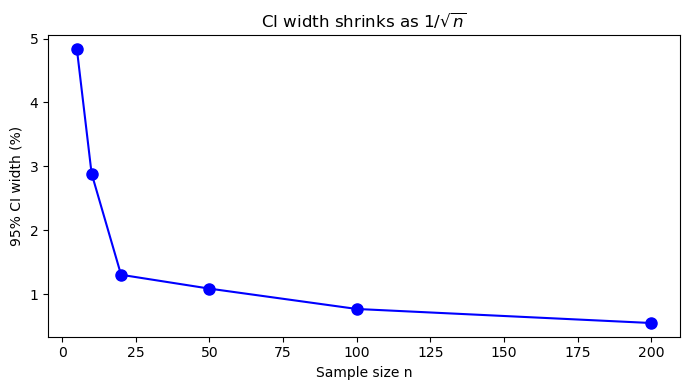

In [18]:
# ── How CI width shrinks with sample size ─────────────────────────────────────
rng   = np.random.default_rng(seed=5)
true_mu, true_sigma = 88.0, 2.0

ns     = [5, 10, 20, 50, 100, 200]
widths = []

print(f"{'n':>5}  {'Mean':>8}  {'95% CI width':>14}  {'SE':>8}")
print("-" * 45)
for n_val in ns:
    sample = rng.normal(true_mu, true_sigma, n_val)
    xb = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n_val)
    t  = stats.t.ppf(0.975, df=n_val-1)
    width = 2 * t * se
    widths.append(width)
    print(f"{n_val:>5}  {xb:>8.4f}  {width:>14.4f}  {se:>8.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, widths, 'bo-', markersize=8)
ax.set_xlabel('Sample size n')
ax.set_ylabel('95% CI width (%)')
ax.set_title('CI width shrinks as $1/\\sqrt{n}$')
plt.tight_layout()
plt.show()

> **Instructor Note — CI Width vs. n**
>
> Run the cell. Point to the table and the plot.
>
> *"As n increases from 5 to 200, the CI width drops from about 2.5% down to 0.3%. Each time n quadruples, the width roughly halves — that's the 1/√n relationship."*
>
> Pose the experimental design question: *"If I need my 95% CI width to be ±0.5% (total width 1%), and my std dev is about 2%, how many batches do I need?"*
>
> Work it out: width = 2 × t × s/√n ≈ 2 × 2 × 2/√n = 8/√n. Set 8/√n = 1 → √n = 8 → n = 64.
>
> *"So 64 batches to estimate the mean within ±0.5%. That's the last question from the motivation slide — answered."*
>
> **Key message:** *"The CI width formula quantifies the fundamental trade-off between experimental effort and precision. If someone asks 'how many experiments do I need?', you now have the math to answer it."*

### Reading the CI output

From the code above, the 95% CI for the batch yield mean is approximately **[86.7%, 88.7%]**.

**How to interpret this:**
- Our point estimate (sample mean) is 87.71%
- We are 95% confident the *true* long-run mean yield is between 86.7% and 88.7%
- The target is 88.0% — since 88.0% is **inside** the 95% CI, we cannot conclude the process is off-target at the 5% significance level
- With only 15 batches, there is too much uncertainty to be conclusive; we need more data

**Notice the trade-off:** The 99% CI is wider than the 95% CI, which is wider than the 90% CI. More confidence requires a wider interval — this makes intuitive sense.

**Notice the effect of $n$:** The cell below shows that CI width shrinks proportionally to $1/\sqrt{n}$. To cut the CI in half, we need 4× more samples. This guides experimental design: "How many batches do I need to estimate the mean within ±0.5%?"

(13.6)=
## 13.6 Monte Carlo Simulation

**Monte Carlo simulation** uses random sampling to estimate quantities that are difficult or impossible to compute analytically. It is named after the Monte Carlo casino — randomness is the core mechanism.

### The core idea

1. Model each uncertain input as a probability distribution
2. Draw thousands of random samples from those input distributions
3. Compute the output for each combination of sampled inputs
4. Analyze the resulting distribution of outputs

This approach is powerful because it:
- Works for **any function**, no matter how nonlinear or complex
- Handles **any distribution** for inputs, not just normal
- Gives you the **full output distribution**, not just a mean and standard deviation
- Can be extended to **correlated inputs** (e.g., pressure and temperature are not independent in a process)

### Comparison to analytical error propagation

The standard first-order (linearized) uncertainty propagation formula is:

$$
\sigma_f^2 \approx \sum_i \left(\frac{\partial f}{\partial x_i}\right)^2 \sigma_{x_i}^2
\quad \text{(assuming independent inputs)}
$$

This works well for smooth, nearly linear functions with small uncertainties. Monte Carlo is more general:

| Method | Pros | Cons |
|--------|------|------|
| Analytical (first-order) | Fast, exact for linear functions | Requires derivatives; fails for nonlinear functions; assumes normal inputs |
| Monte Carlo | No derivatives needed; handles any distribution; reveals full output distribution | Slower; statistical noise in estimates |

**ChE applications of Monte Carlo:**
- **Uncertainty propagation** through thermodynamic calculations (e.g., how does uncertainty in $E_a$ affect predicted conversion?)
- **Process reliability** — what fraction of operating conditions lead to off-spec product?
- **Risk assessment** — what is the probability of exceeding a safety threshold?
- **Equipment sizing** — given uncertain feed compositions, what reactor volume ensures 99% of scenarios achieve desired conversion?
- **Financial analysis** — uncertainty in raw material costs, utility prices, and yields propagates to process economics

> **Instructor Note — 13.6 Monte Carlo Simulation**
>
> Transition: *"Everything we've done so far has been about analyzing data we already have. Monte Carlo simulation is about predicting the future — simulating what will happen given uncertain inputs."*
>
> **Sell the concept first:** *"This is one of the most used computational tools in the chemical industry. Process design groups at large companies run Monte Carlo simulations to understand how uncertainty in raw material quality, utility costs, kinetic parameters, and equipment performance propagates to uncertainty in process economics and product quality."*
>
> **Walk through the 4 steps out loud:**
> 1. *"Identify which inputs have uncertainty. Model each as a distribution — normal if you have mean and std, uniform if you only know bounds."*
> 2. *"Draw, say, 100,000 random input sets. Each is a plausible scenario."*
> 3. *"Run your calculation for each scenario. This is just a vectorized numpy operation — it takes milliseconds."*
> 4. *"Analyze the outputs. Build a histogram. Compute percentiles. Ask: what fraction of scenarios lead to failure?"*
>
> **On the comparison table:** *"Analytical error propagation requires taking derivatives — hard for complex models, and only valid for small uncertainties and near-linear functions. Monte Carlo has none of these restrictions. If you can write a function in Python, you can propagate uncertainty through it."*
>
> *"The only cost of Monte Carlo is compute time — and with N=100,000 on a modern laptop, that's under a second for most problems."*

(13.7.1)=
### 13.7.1 Error Propagation: Arrhenius Rate Constant

The Arrhenius equation is fundamental to reaction engineering:
$$k = A \exp\!\left(-\frac{E_a}{RT}\right)$$

Both $E_a$ and $T$ are measured quantities with uncertainty. Because $k$ depends **exponentially** on $E_a$ and $T$, even small uncertainties in these inputs can produce surprisingly large uncertainty in $k$.

**Step-by-step Monte Carlo approach:**
1. Model $E_a$ and $T$ as normal distributions (measurement errors are approximately normally distributed)
2. Draw $N = 100{,}000$ independent pairs $(E_a^{(i)}, T^{(i)})$
3. Compute $k^{(i)} = A \exp(-E_a^{(i)} / (R T^{(i)}))$ for each pair
4. Analyze the distribution of $k^{(i)}$: mean, std, percentiles

**Given:**
- $A = 1 \times 10^8$ s$^{-1}$ (exact, no uncertainty)
- $E_a = 75{,}000 \pm 500$ J/mol — normal distribution: $E_a \sim \mathcal{N}(75000, 500^2)$
- $T = 500 \pm 1.5$ K — normal distribution: $T \sim \mathcal{N}(500, 1.5^2)$
- $R = 8.314$ J/(mol·K)

The notation $\pm$ here refers to 1 standard deviation (the 68% confidence range for a normal distribution).

> **Instructor Note — Arrhenius MC Setup**
>
> *"Our first Monte Carlo example: the Arrhenius rate constant. This is perfect for ChE students because you've all worked with this equation."*
>
> Walk through the problem setup:
> - *"Pre-exponential A is known exactly — no uncertainty."*
> - *"Activation energy Ea = 75,000 J/mol with a standard deviation of 500 J/mol. This could come from fitting an Arrhenius plot — the fit has some uncertainty."*
> - *"Temperature T = 500 K with std dev 1.5 K — from a thermocouple reading."*
>
> *"The question is: given these two uncertain inputs, how uncertain is k? Because k depends exponentially on Ea and T, a small uncertainty in those inputs gets amplified into a larger uncertainty in k."*
>
> **Motivate why MC is better than the analytical formula here:**
> *"The first-order uncertainty formula would require ∂k/∂Ea and ∂k/∂T. You could compute those — they're straightforward. But the Arrhenius function is exponential and highly nonlinear. The first-order approximation underestimates the true uncertainty, especially for large uncertainties. Monte Carlo gives the exact answer."*

In [ ]:
# ── Monte Carlo error propagation: Arrhenius rate constant ────────────────────
rng    = np.random.default_rng(seed=42)
N_mc   = 100_000
R      = 8.314
A_pre  = 1e8

# Step 1: Define input distributions
Ea_mu, Ea_sig = 75_000.0, 500.0    # J/mol  — mean and std dev of Ea measurement
T_mu,  T_sig  = 500.0,    1.5      # K      — mean and std dev of T measurement

# Step 2: Draw N_mc random samples from each input distribution
Ea_samples = rng.normal(Ea_mu, Ea_sig, N_mc)   # shape: (N_mc,)
T_samples  = rng.normal(T_mu,  T_sig,  N_mc)   # shape: (N_mc,)

# Step 3: Evaluate the function for each sample pair
k_samples = A_pre * np.exp(-Ea_samples / (R * T_samples))

# Nominal (deterministic) value using the mean inputs
k_nominal = A_pre * np.exp(-Ea_mu / (R * T_mu))

# Step 4: Analyze the output distribution
print(f"Nominal k at (Ea={Ea_mu:.0f} J/mol, T={T_mu:.0f} K):")
print(f"  k_nominal = {k_nominal:.6f} s⁻¹")
print()
print(f"Monte Carlo results (N = {N_mc:,}):")
print(f"  k mean  = {np.mean(k_samples):.6f} s⁻¹  (slightly > nominal due to nonlinearity)")
print(f"  k std   = {np.std(k_samples, ddof=1):.6f} s⁻¹")
print(f"  k CV    = {100*np.std(k_samples)/np.mean(k_samples):.2f}%  (coefficient of variation — relative uncertainty)")
print()
print(f"  95% range of k:")
print(f"    2.5th percentile  = {np.percentile(k_samples,  2.5):.6f} s⁻¹")
print(f"    97.5th percentile = {np.percentile(k_samples, 97.5):.6f} s⁻¹")
print()
print(f"  Interpretation: 95% of the time, k falls in this range due to")
print(f"  measurement uncertainty in Ea and T alone.")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(Ea_samples, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(Ea_mu, color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('$E_a$ (J/mol)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Input: $E_a$ ~ N({Ea_mu:.0f}, {Ea_sig:.0f}²)')
axes[0].legend()

axes[1].hist(T_samples, bins=60, color='orange', edgecolor='white', alpha=0.8)
axes[1].axvline(T_mu, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].set_xlabel('T (K)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Input: T ~ N({T_mu:.0f}, {T_sig:.1f}²)')
axes[1].legend()

axes[2].hist(k_samples, bins=80, color='green', edgecolor='white', alpha=0.8, density=True)
axes[2].axvline(k_nominal, color='red', linestyle='--', linewidth=2, label='k nominal')
axes[2].axvline(np.mean(k_samples), color='blue', linestyle='-', linewidth=2, label='k MC mean')
axes[2].set_xlabel('k (s⁻¹)'); axes[2].set_ylabel('Density')
axes[2].set_title('Output: k distribution\n(skewed due to exponential nonlinearity)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print()
print("Note: k_mean > k_nominal — Jensen's inequality: for a convex function f,")
print("E[f(X)] > f(E[X]). The exponential function is convex, so the mean k from")
print("Monte Carlo slightly exceeds the nominal k computed at the mean inputs.")

> **Instructor Note — Arrhenius MC Code**
>
> Walk through the code structure before running it, pointing to the four numbered steps in the comments.
>
> *"Step 1: we define the distributions. Step 2: we draw 100,000 samples from each — one line of code. Step 3: we compute k for all 100,000 scenarios simultaneously — vectorized numpy, no loop needed. Step 4: we analyze the results."*
>
> Run the cell. Walk through the output:
>
> *"Nominal k = [read value]. This is what you'd compute ignoring all uncertainty — plug in the mean values and get one answer."*
>
> *"Monte Carlo mean is slightly higher than nominal. This is Jensen's inequality — because the exponential is a convex function, the expected value of the output exceeds the output at the expected input. For the Arrhenius equation this effect is real and matters."*
>
> *"The CV (coefficient of variation) is [read value]% — this is the relative uncertainty in k. A CV of, say, 10% means k is uncertain by ±10% relative to its mean."*
>
> Point to the three plots: *"Left two panels: the inputs. Both look normally distributed as expected. Right panel: the output k distribution — notice it's slightly right-skewed, not perfectly normal. This is what the analytical formula would miss."*
>
> *"The 95% range gives you: 95% of the time, k will fall between [read lower] and [read upper]. This is directly useful for reactor design — you'd size the reactor for the worst-case (low k) scenario."*

(13.7.2)=
### 13.7.2 Process Reliability: Fraction of Batches Meeting Spec

A key question in process design and operations: **what fraction of batches will meet product specifications** when operating conditions fluctuate?

This can't be answered by just computing the nominal output — you need to know how variability in inputs propagates to variability in the output.

**Problem setup:**

A chemical product must have purity $\geq 97.5\%$ to be sold. The purity model is:

$$
\text{Purity} = 100 \times \left(1 - 0.04\,e^{-k(T)\,\tau} \right)
$$

where:
- $k(T) = 0.1 \exp\!\left(-5000/T\right)$ is a simplified rate constant (s$^{-1}$)
- $\tau$ (residence time, s) varies: $\tau \sim \mathcal{N}(120, 10^2)$ — due to flow control variability
- $T$ (temperature, K) varies: $T \sim \mathcal{N}(400, 5^2)$ — due to heat exchanger control variability

**Step-by-step:**
1. Sample 200,000 operating scenarios $(\tau^{(i)}, T^{(i)})$
2. Compute purity for each scenario
3. Count what fraction fall below the 97.5% spec
4. Visualize the purity distribution and identify which conditions cause failures

> **Instructor Note — Process Reliability Setup**
>
> *"Now a second Monte Carlo application — process reliability. This directly answers the question: what fraction of our batches will fail spec?"*
>
> Explain the purity model: *"Purity depends on how long the reactant spends in the reactor (residence time τ) and the temperature T. Both vary from batch to batch due to control system variability."*
>
> *"The residence time varies because the feed flow controller isn't perfect — it overshoots and undershoots. The temperature varies because the heat exchanger control loop responds to disturbances. We model both as normal distributions centered on the nominal values."*
>
> *"The nominal operating point would give a certain purity. But with real variability, sometimes τ is short and T is low — purity drops. How often? Monte Carlo tells us."*
>
> **Ask students before running:** *"If the nominal τ=120s and T=400K gives, say, 98% purity — would you expect a lot of batches to fail the 97.5% spec? Take a guess."* Get responses, then reveal with the code.

Monte Carlo reliability analysis  (N = 200,000)
  Purity mean  = 96.000%
  Purity std   = 0.000%
  Purity 5th percentile  = 96.000%
  Spec limit             = 97.5%
  Fraction BELOW spec    = 1.0000  (100.00% failure rate)
  Fraction ABOVE spec    = 0.0000  (0.00% pass rate)


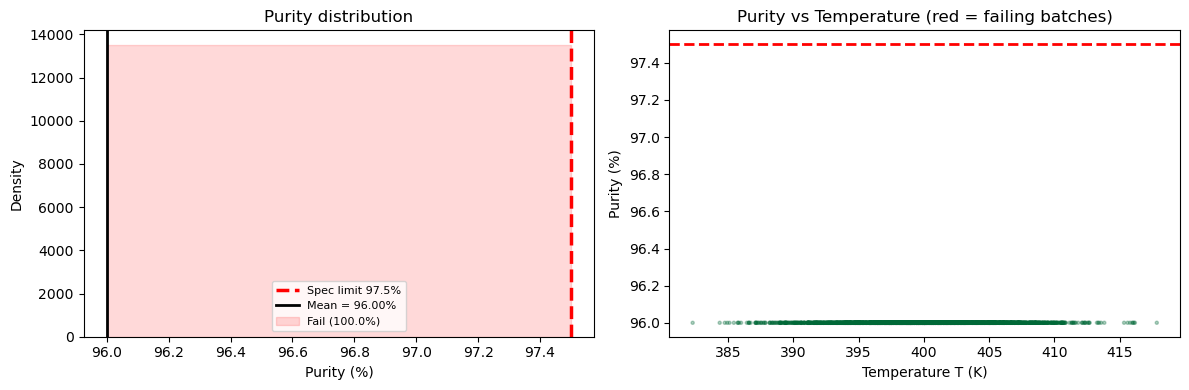

In [20]:
# ── Monte Carlo process reliability ───────────────────────────────────────────
rng   = np.random.default_rng(seed=17)
N_mc  = 200_000

# Uncertain inputs
tau_samples = rng.normal(120.0, 10.0,  N_mc)    # residence time (s)
T_samples2  = rng.normal(400.0,  5.0,  N_mc)    # temperature (K)

# Simplified rate constant and purity model
k_samples2  = 0.1 * np.exp(-5000.0 / T_samples2)
purity      = 100.0 * (1.0 - 0.04 * np.exp(-k_samples2 * tau_samples))

spec_limit  = 97.5   # %
frac_fail   = np.mean(purity < spec_limit)
frac_pass   = 1.0 - frac_fail

print(f"Monte Carlo reliability analysis  (N = {N_mc:,})")
print(f"  Purity mean  = {np.mean(purity):.3f}%")
print(f"  Purity std   = {np.std(purity, ddof=1):.3f}%")
print(f"  Purity 5th percentile  = {np.percentile(purity, 5):.3f}%")
print(f"  Spec limit             = {spec_limit}%")
print(f"  Fraction BELOW spec    = {frac_fail:.4f}  ({100*frac_fail:.2f}% failure rate)")
print(f"  Fraction ABOVE spec    = {frac_pass:.4f}  ({100*frac_pass:.2f}% pass rate)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(purity, bins=80, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(spec_limit, color='red', linestyle='--', linewidth=2.5, label=f'Spec limit {spec_limit}%')
ax.axvline(np.mean(purity), color='black', linestyle='-', linewidth=2, label=f'Mean = {np.mean(purity):.2f}%')
# shade the failing region
ax.fill_between([purity.min(), spec_limit],
                0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                alpha=0.15, color='red', label=f'Fail ({100*frac_fail:.1f}%)')
ax.set_xlabel('Purity (%)')
ax.set_ylabel('Density')
ax.set_title('Purity distribution')
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(T_samples2[:3000], purity[:3000],
           c=(purity[:3000] < spec_limit), cmap='RdYlGn_r',
           alpha=0.3, s=5)
ax.axhline(spec_limit, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Temperature T (K)')
ax.set_ylabel('Purity (%)')
ax.set_title('Purity vs Temperature (red = failing batches)')

plt.tight_layout()
plt.show()

> **Instructor Note — Process Reliability Code**
>
> Run the cell. Point to the output first, then the plots.
>
> Read the failure rate: *"[Read failure fraction]% of batches fail the 97.5% spec. That's roughly 1 in [X] batches. For a process running 500 batches per year, that's [500 × fraction] failed batches per year — each one is wasted product and cost."*
>
> Point to the **left plot** (purity histogram): *"The red dashed line is the spec limit at 97.5%. The shaded area to the left is the failing fraction. Notice the mean is comfortably above spec, but the left tail dips below."*
>
> Point to the **right plot** (scatter, purity vs temperature): *"Red points are failing batches. They cluster at low temperatures — which makes physical sense, because lower T means lower rate constant k, meaning the reaction goes to lower conversion."*
>
> **Engineering insight:** *"This scatter plot tells you where to focus process improvement. The failures are caused primarily by low temperature, not by low residence time. So the highest-impact fix is to improve temperature control — tighten the heat exchanger control loop. This is how Monte Carlo guides process improvement."*
>
> *"Without simulation, you'd run the process, accumulate failures, and eventually figure this out empirically — at significant cost. Simulation lets you identify this in minutes, before you build anything."*

(13.7.3)=
### 13.7.3 Classic Monte Carlo: Estimating π

Before applying Monte Carlo to engineering problems, let's build intuition with a classic example: estimating $\pi$ by "throwing darts."

**The idea:** Randomly throw darts at a unit square $[0,1]^2$. A quarter-circle of radius 1 has area $\pi/4$. If darts are thrown uniformly, the fraction landing inside the quarter-circle equals the ratio of areas:

$$
\frac{\text{darts inside quarter-circle}}{\text{total darts}} \approx \frac{\pi/4}{1} = \frac{\pi}{4}
\quad \Rightarrow \quad
\hat{\pi} = 4 \times \frac{\text{darts inside}}{\text{total darts}}
$$

**Why this is instructive for ChE:**
- It demonstrates the **law of large numbers**: the Monte Carlo estimate converges to the true value as $N \to \infty$
- The error shrinks as $\sim 1/\sqrt{N}$ — the same scaling as SE = $\sigma/\sqrt{n}$
- It shows that Monte Carlo can compute quantities defined by geometric or probabilistic conditions, not just explicit formulas

**Convergence rate:** To gain one extra decimal place of accuracy, you need 100× more samples. This is Monte Carlo's weakness — it is accurate but not efficient. For 1D integrals, direct numerical integration (Chapter 11) is far more efficient. Monte Carlo shines for **high-dimensional** problems where the number of integration variables makes standard methods impractical.

> **Instructor Note — π Estimation**
>
> *"Before we close, let's do the classic Monte Carlo example — estimating π by throwing darts. This isn't a ChE problem, but it builds intuition for why Monte Carlo works and how it converges."*
>
> Explain the geometry: *"Imagine a unit square with a quarter-circle inscribed in the lower-left corner. If we throw darts uniformly at the square, the fraction landing inside the quarter-circle equals the ratio of their areas: π/4 over 1. So we multiply the fraction by 4 to get π."*
>
> *"The 'darts' are just random (x,y) pairs from Uniform(0,1). A dart is 'inside' if x² + y² ≤ 1."*

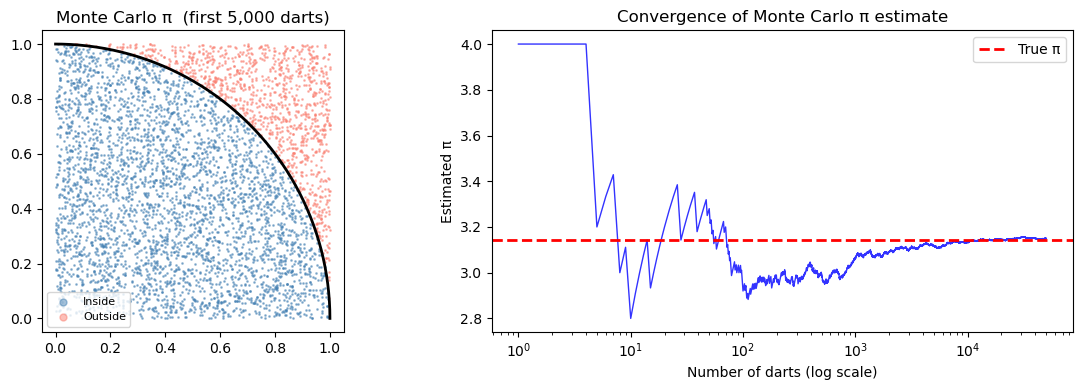

True π               = 3.14159265
MC estimate (N=50,000) = 3.14968000
Error                = 8.09e-03


In [21]:
# ── Monte Carlo estimate of π ─────────────────────────────────────────────────
rng    = np.random.default_rng(seed=0)
N_darts = 50_000

x_darts = rng.random(N_darts)
y_darts = rng.random(N_darts)
inside  = (x_darts**2 + y_darts**2) <= 1.0

# Running estimate as we add more darts
N_run    = np.arange(1, N_darts + 1)
pi_est   = 4.0 * np.cumsum(inside) / N_run

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dart scatter plot (show first 5000)
ax = axes[0]
n_show = 5000
ax.scatter(x_darts[:n_show][inside[:n_show]],  y_darts[:n_show][inside[:n_show]],
           s=1, color='steelblue', alpha=0.5, label='Inside')
ax.scatter(x_darts[:n_show][~inside[:n_show]], y_darts[:n_show][~inside[:n_show]],
           s=1, color='salmon',    alpha=0.5, label='Outside')
theta = np.linspace(0, np.pi/2, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo π  (first {n_show:,} darts)')
ax.legend(fontsize=8, markerscale=5)

# Convergence
ax = axes[1]
ax.semilogx(N_run, pi_est, 'b-', linewidth=1, alpha=0.8)
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label='True π')
ax.set_xlabel('Number of darts (log scale)')
ax.set_ylabel('Estimated π')
ax.set_title('Convergence of Monte Carlo π estimate')
ax.legend()

plt.tight_layout()
plt.show()

print(f"True π               = {np.pi:.8f}")
print(f"MC estimate (N={N_darts:,}) = {pi_est[-1]:.8f}")
print(f"Error                = {abs(pi_est[-1] - np.pi):.2e}")

> **Instructor Note — π Estimation Code**
>
> Run the cell. Let students look at both plots.
>
> **Left plot (dart scatter):** *"Blue dots landed inside the quarter-circle, red outside. With 5000 darts shown, you can clearly see the arc of the quarter-circle emerging from the randomness. This is beautiful — order from chaos."*
>
> **Right plot (convergence):** *"With 10 darts, our estimate of π is way off. With 1000 darts, we're getting close. With 50,000 darts, we're accurate to about 3 decimal places."*
>
> Point to the convergence rate: *"The error shrinks as 1/√N. To gain one more decimal place of accuracy, you need 100× more darts. This is Monte Carlo's fundamental limitation for smooth problems."*
>
> Read the final estimate: *"With 50,000 darts, we get π ≈ [read value], error ≈ [read error]. That's pretty good for just counting random points."*
>
> **Connect back to engineering:** *"The convergence we see here is the same convergence that governs Monte Carlo for process simulations. With 10,000 scenarios, uncertainty estimates (like failure fractions) are accurate to about 1% of their true value — usually sufficient for engineering decisions."*
>
> *"For problems with 10+ input variables, Monte Carlo is often the only practical approach. Direct numerical integration over 10 dimensions would require billions of function evaluations; Monte Carlo converges at the same 1/√N rate regardless of dimensionality."*

**Summary**

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Sample mean** | `np.mean(x)` | Center of data |
| **Sample std dev** | `np.std(x, ddof=1)` | Spread of data (always `ddof=1` for samples) |
| **Percentile** | `np.percentile(x, q)` | Quantify tails, IQR |
| **Descriptive summary** | `scipy.stats.describe(x)` | Quick overview incl. skewness, kurtosis |
| **Random generation** | `rng = np.random.default_rng(seed)` | Reproducible random sampling |
| **Normal distribution** | `stats.norm(mu, sigma)` | Measurement errors, process variability |
| **Uniform distribution** | `stats.uniform(loc, scale)` | Bounded uncertainty, no preference |
| **CDF / PPF** | `.cdf(x)` / `.ppf(p)` | Probability below $x$ / value at $p$-th percentile |
| **Central Limit Theorem** | $\bar{X} \sim \mathcal{N}(\mu, \sigma^2/n)$ | Justifies normality of sample means |
| **Confidence interval** | `stats.t.interval(conf, df, loc, scale)` | Range for the true mean |
| **Monte Carlo** | Sample inputs → compute outputs → analyze | Uncertainty propagation, reliability |

> **Instructor Note — Chapter Wrap-Up**
>
> *"Let's come back to the questions from the beginning. We had a batch reactor with 15 yield measurements. We can now answer every question:"*
>
> - *"What is the average yield and how much does it vary? → Mean 87.71%, std 1.84%."*
> - *"Is the process meeting the 88% target on average? → The 95% CI is [86.70, 88.73%]. The target 88% is inside the interval — we cannot reject that the process is on target with n=15."*
> - *"What fraction of future batches will fall below 85%? → If yield ~ N(88, 2²), then P(yield < 85) ≈ 6.7%. We'd need to fit a distribution to our data first (Section 13.8)."*
> - *"How many measurements to estimate the mean within ±0.5%? → About 64 batches."*
>
> **Big picture:** *"Statistics is not just a set of formulas. It's a framework for reasoning carefully about uncertainty. Every measurement has uncertainty. Every model has parameters with uncertainty. Every prediction has uncertainty. Statistics lets you be precise about all of that."*
>
> **What we didn't cover:** Hypothesis testing (t-tests, ANOVA), regression uncertainty, design of experiments. These build on everything you've learned today and are covered in later courses.
>
> **For the homework/lab:** Remind students that any Monte Carlo simulation must use a fixed seed, report N (number of simulations), and justify their choice of input distributions.
>
> **Office hours reminder / questions.**